# Vision-Based Ciliary Beat Frequency Analysis

This notebook implements a vision-based pipeline to estimate ciliary beat frequency (CBF) from microscopy videos.

The workflow includes:
1. Video preprocessing
2. Motion signal extraction
3. Frequency analysis
4. Feature generation
5. Machine learning classification

In [1]:
#Important Libraries and methods for the project
import os
import warnings
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.fft import rfft, rfftfreq
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Check if optional packages are available
try:
    import tensorflow as tf
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False

try:
    import xgboost
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('TensorFlow available:', TENSORFLOW_AVAILABLE)
print('XGBoost available:', XGBOOST_AVAILABLE)

TensorFlow available: True
XGBoost available: True


In [2]:
def video_to_array(video_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))

    frames = []
    count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray.astype(np.float32))
        count += 1
        if max_frames is not None and count >= max_frames:
            break

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames read from: {video_path}")

    video_np_array = np.stack(frames, axis=0)  # (T, H, W)
    return video_np_array, fps

In [3]:
def split_video(video_matrix, n_split_axis):
    T, H, W = video_matrix.shape
    step_h = int(np.ceil(H / n_split_axis))
    step_w = int(np.ceil(W / n_split_axis))

    rois = []
    meta = []  # (roi_id, x, y, w, h)
    roi_id = 0

    for gy in range(n_split_axis):
        y0 = gy * step_h
        y1 = min((gy + 1) * step_h, H)
        for gx in range(n_split_axis):
            x0 = gx * step_w
            x1 = min((gx + 1) * step_w, W)
            roi = video_matrix[:, y0:y1, x0:x1]
            if roi.size == 0:
                continue
            rois.append(roi)
            meta.append((roi_id, x0, y0, x1 - x0, y1 - y0))
            roi_id += 1

    return rois, meta

In [4]:
def roi_mean_intensity(roi_cube):
    return roi_cube.mean(axis=(1, 2))

In [5]:
def center_signal(x):
    x = np.asarray(x, dtype=float)
    return x - np.mean(x)

In [6]:
def bandpass_filter(x, fs, low=2.0, high=30.0, order=2):
    nyq = 0.5 * fs
    low_cut = max(low / nyq, 1e-6)
    high_cut = min(high / nyq, 0.99)
    if low_cut >= high_cut:
        return x
    b, a = butter(order, [low_cut, high_cut], btype="band")
    return filtfilt(b, a, x)

In [7]:
def fft_peak(signal_1d, fs, fmin=2.0, fmax=30.0):
    s = np.asarray(signal_1d, dtype=float)
    if s.size < 8:
        return np.nan, np.nan, s

    s = center_signal(s)
    s_filt = bandpass_filter(s, fs, fmin, fmax, order=2)

    spec = rfft(s_filt)
    freqs = rfftfreq(len(s_filt), d=1.0 / fs)
    mags = np.abs(spec)

    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return np.nan, np.nan, s_filt

    idx = np.argmax(mags[mask])
    best_freq = float(freqs[mask][idx])
    best_mag = float(mags[mask][idx])

    return best_freq, best_mag, s_filt

In [8]:
def skeletonize_binary(binary_img):
    """
    Skeletonize using skimage if available, otherwise OpenCV thinning if available,
    otherwise return the binary image (still saves something).
    """
    b = (binary_img > 0).astype(np.uint8) * 255

    # option 1: skimage
    try:
        from skimage.morphology import skeletonize
        sk = skeletonize((b > 0))
        return (sk.astype(np.uint8) * 255)
    except Exception:
        pass

In [9]:
from fileinput import filename
from os import name


def save_skeleton_demo(frame_gray, out_path):
    """
    Takes ONE grayscale frame, makes a binary + skeleton image,
    saves the skeleton image, and returns both images.
    """
    g = frame_gray.astype(np.uint8)

    # Gaussian blur to reduce tiny noise
    g = cv2.GaussianBlur(g, (5, 5), 0)

    # threshold
    bin_img = cv2.adaptiveThreshold(
        g, 255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY_INV,
        blockSize=31,
        C=5
    )

    # clean specks
    kernel = np.ones((3, 3), np.uint8)
    bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)

    skel = skeletonize_binary(bin_img)
    cv2.imwrite(out_path, skel)
    return bin_img, skel  

def label_from_filename(filename):
    name = str(filename).lower()
    if "healthy" in name:
        return "Healthy"
    return "PCD"


In [10]:
def process_videos_folder(videodir, outdir, extensions=None, ngrid=10, maxframes=300, fmin=2.0, fmax=30.0):
    if extensions is None:
        extensions = ['.avi', '.mov', '.mp4', '.mkv']

    if not os.path.isdir(videodir):
        raise RuntimeError(f"Video directory not found: {videodir}")

    os.makedirs(outdir, exist_ok=True)
    ext_set = {e.lower() for e in extensions}

    files = [
        f for f in os.listdir(videodir)
        if os.path.isfile(os.path.join(videodir, f)) and os.path.splitext(f)[1].lower() in ext_set
    ]

    if len(files) == 0:
        print(f"No videos found in: {videodir}")
        empty_df = pd.DataFrame(columns=['video', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])
        empty_df.to_csv(os.path.join(outdir, "cbf_per_video.csv"), index=False)
        return empty_df

    roi_rows = []

    for fname in files:
        fpath = os.path.join(videodir, fname)
        print(f"Processing: {fname}")

        try:
            video_np_array, fps = video_to_array(fpath, max_frames=maxframes)

            # save one skeleton demo frame per video
            skel_out = os.path.join(outdir, f"{os.path.splitext(fname)[0]}_skeleton.png")
            save_skeleton_demo(video_np_array[0], skel_out)

            rois, meta = split_video(video_np_array, ngrid)
            label = label_from_filename(fname)

            for roi, m in zip(rois, meta):
                roi_id = m[0]
                x = roi_mean_intensity(roi)
                cbf_hz, peak_mag, x_filt = fft_peak(x, fs=fps, fmin=fmin, fmax=fmax)

                var_val = float(np.var(x_filt)) if np.size(x_filt) else np.nan
                z = np.asarray(x_filt, dtype=float)
                zcr_val = float(np.mean(np.abs(np.diff(np.sign(z))) > 0)) if z.size > 1 else np.nan

                roi_rows.append({
                    'video': fname,
                    'roi_id': roi_id,
                    'label': label,
                    'cbf_hz': cbf_hz,
                    'peak_mag': peak_mag,
                    'var': var_val,
                    'zcr': zcr_val
                })

        except Exception as e:
            print(f"Skipped {fname}: {e}")

    roi_df = pd.DataFrame(roi_rows)
    if roi_df.empty:
        roi_df = pd.DataFrame(columns=['video', 'roi_id', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])

    roi_csv = os.path.join(outdir, "cbf_per_roi.csv")
    roi_df.to_csv(roi_csv, index=False)

    video_df = (
    roi_df.groupby(['video','label'], as_index=False)[
        ['cbf_hz','peak_mag','var','zcr']
    ].max()
)

    video_csv = os.path.join(outdir, "cbf_per_video.csv")
    video_df.to_csv(video_csv, index=False)

    print(f"Saved ROI-level features to: {roi_csv}")
    print(f"Saved video-level features to: {video_csv}")
    return video_df


if __name__ == "__main__":

    videodir = r"C:\Users\Ssehra\Desktop\PCD\Data_videos"
    outdir   = r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency"

    import os
    print("Using videos from:", videodir, "| exists?", os.path.isdir(videodir))
    print("Saving outputs to:", outdir)

    process_videos_folder(
        videodir=videodir,
        outdir=outdir,
        extensions=['.avi', '.mov', '.mp4', '.mkv', '.MOV', '.AVI'],
        ngrid=10,
        maxframes=300,
        fmin=2.0,
        fmax=30.0
    )

Using videos from:

 C:\Users\Ssehra\Desktop\PCD\Data_videos | exists? True
Saving outputs to: C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency
Processing: ciliavideo (2).avi
Processing: healthy_1 (1).avi
Processing: healthy_12.mp4
Processing: healthy_13.mp4
Processing: healthy_14.mp4
Processing: healthy_15.mp4
Processing: healthy_16.mp4
Processing: healthy_17.mov
Processing: healthy_18.mov
Processing: healthy_2.mp4
Processing: healthy_3.avi
Processing: healthy_4.avi
Processing: healthy_5.mp4
Processing: PCD_1.mp4
Processing: PCD_10.mp4
Processing: PCD_11.mov
Processing: PCD_12.mov
Processing: PCD_13.mov
Processing: PCD_14.mov
Processing: PCD_15.mov
Processing: PCD_16.mov
Processing: PCD_2.mp4
Processing: PCD_3.mp4
Processing: PCD_4.mp4
Processing: PCD_5.avi
Processing: PCD_5.mp4
Processing: PCD_6.avi
Processing: PCD_7.avi
Processing: PCD_8.avi
Processing: PCD_9.mp4
Saved ROI-level features to: C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_roi.csv
Saved video-level features to

Machine Learing Pipeline

The CBF cutoff values are given from this paper:  https://www.mdpi.com/2075-4418/16/5/704

In [11]:
# Plotting Quantitative analysis of CBF resullts to classify between healthy and PCD samples. 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.stats import entropy as scipy_entropy
from scipy.stats import ttest_ind 
import scipy.stats as stats

In [16]:
video_df = pd.read_csv(r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv")

video_df['label_bin'] = video_df['label'].str.lower().map({
    'healthy':0,
    'pcd':1
})

video_df = video_df[['cbf_hz','var','label_bin']]

scaled = pd.read_csv(r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\Scaled.MT.csv")

scaled['label_bin'] = scaled['Group'].apply(
    lambda x: 0 if x.lower()=="control" else 1
)

scaled = scaled.rename(columns={
    'CBF':'cbf_hz',
    'SEM':'var'
})

scaled = scaled[['cbf_hz','var','label_bin']]

# ---------- COMBINE DATASETS ----------
combined_df = pd.concat([video_df, scaled], ignore_index=True)

print("Total samples:",combined_df.shape)

Total samples: (902, 3)


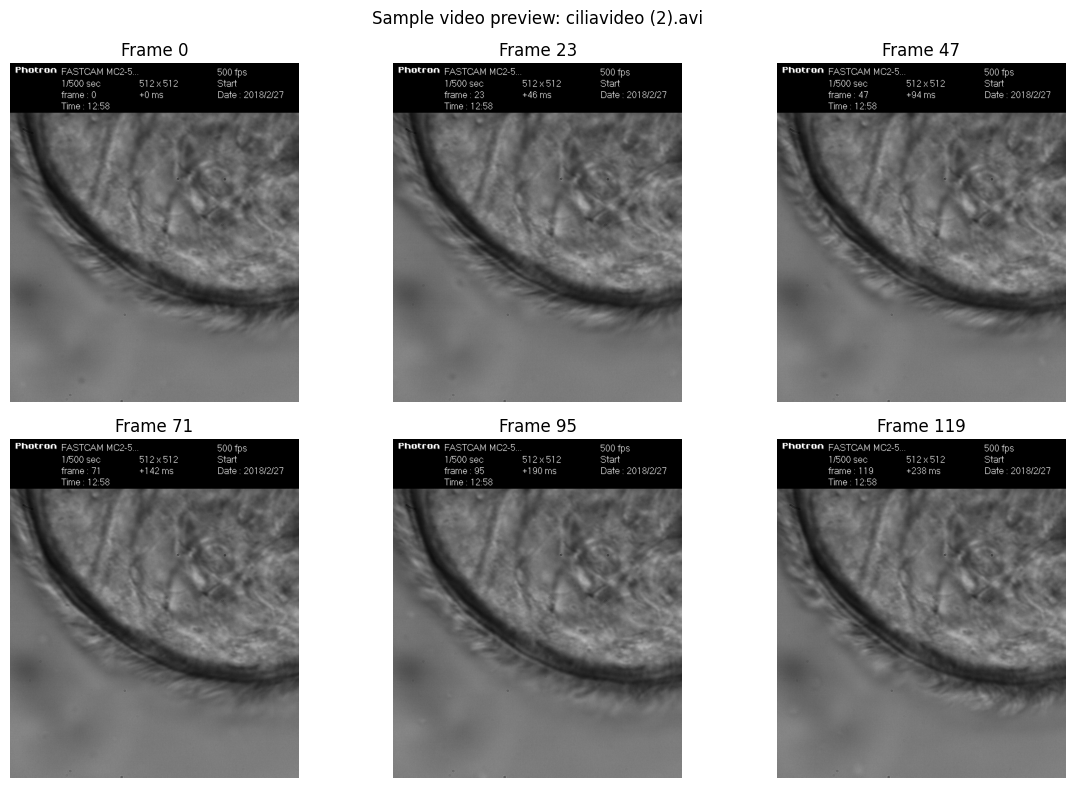

In [17]:
# Show several frames from the sample video to confirm it loaded correctly
if "video_files" not in globals():
    video_files = [
        f for f in os.listdir(videodir)
        if os.path.isfile(os.path.join(videodir, f)) and os.path.splitext(f)[1].lower() in ['.avi', '.mov', '.mp4', '.mkv']
    ]

if "sample_video_path" not in globals():
    sample_video_path = os.path.join(videodir, video_files[0]) if len(video_files) > 0 else None

if sample_video_path is None:
    print("No sample video available. Check 'videodir' and 'video_files'.")
else:
    if "sample_video" not in globals():
        sample_video, sample_fps = video_to_array(sample_video_path, max_frames=120)

    n_show = min(6, sample_video.shape[0])
    idxs = np.linspace(0, sample_video.shape[0] - 1, n_show, dtype=int)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for ax, idx in zip(axes, idxs):
        ax.imshow(sample_video[idx], cmap='gray')
        ax.set_title(f"Frame {idx}")
        ax.axis('off')

    for ax in axes[len(idxs):]:
        ax.axis('off')

    plt.suptitle(f"Sample video preview: {os.path.basename(sample_video_path)}")
    plt.tight_layout()
    plt.show()

In [18]:
#run on a single video to test
sample_video_path = os.path.join(videodir, video_files[0]) if len(video_files) > 0 else None

if sample_video_path is None:
    print("no sample video available.")
else:
    sample_video, sample_fps = video_to_array(sample_video_path, max_frames=120)
    print("sample file =", os.path.basename(sample_video_path))
    print("sample video shape (T, H, W) =", sample_video.shape)
    print("sample fps =", sample_fps)

sample file = ciliavideo (2).avi
sample video shape (T, H, W) = (120, 600, 512)
sample fps = 30.00003000003


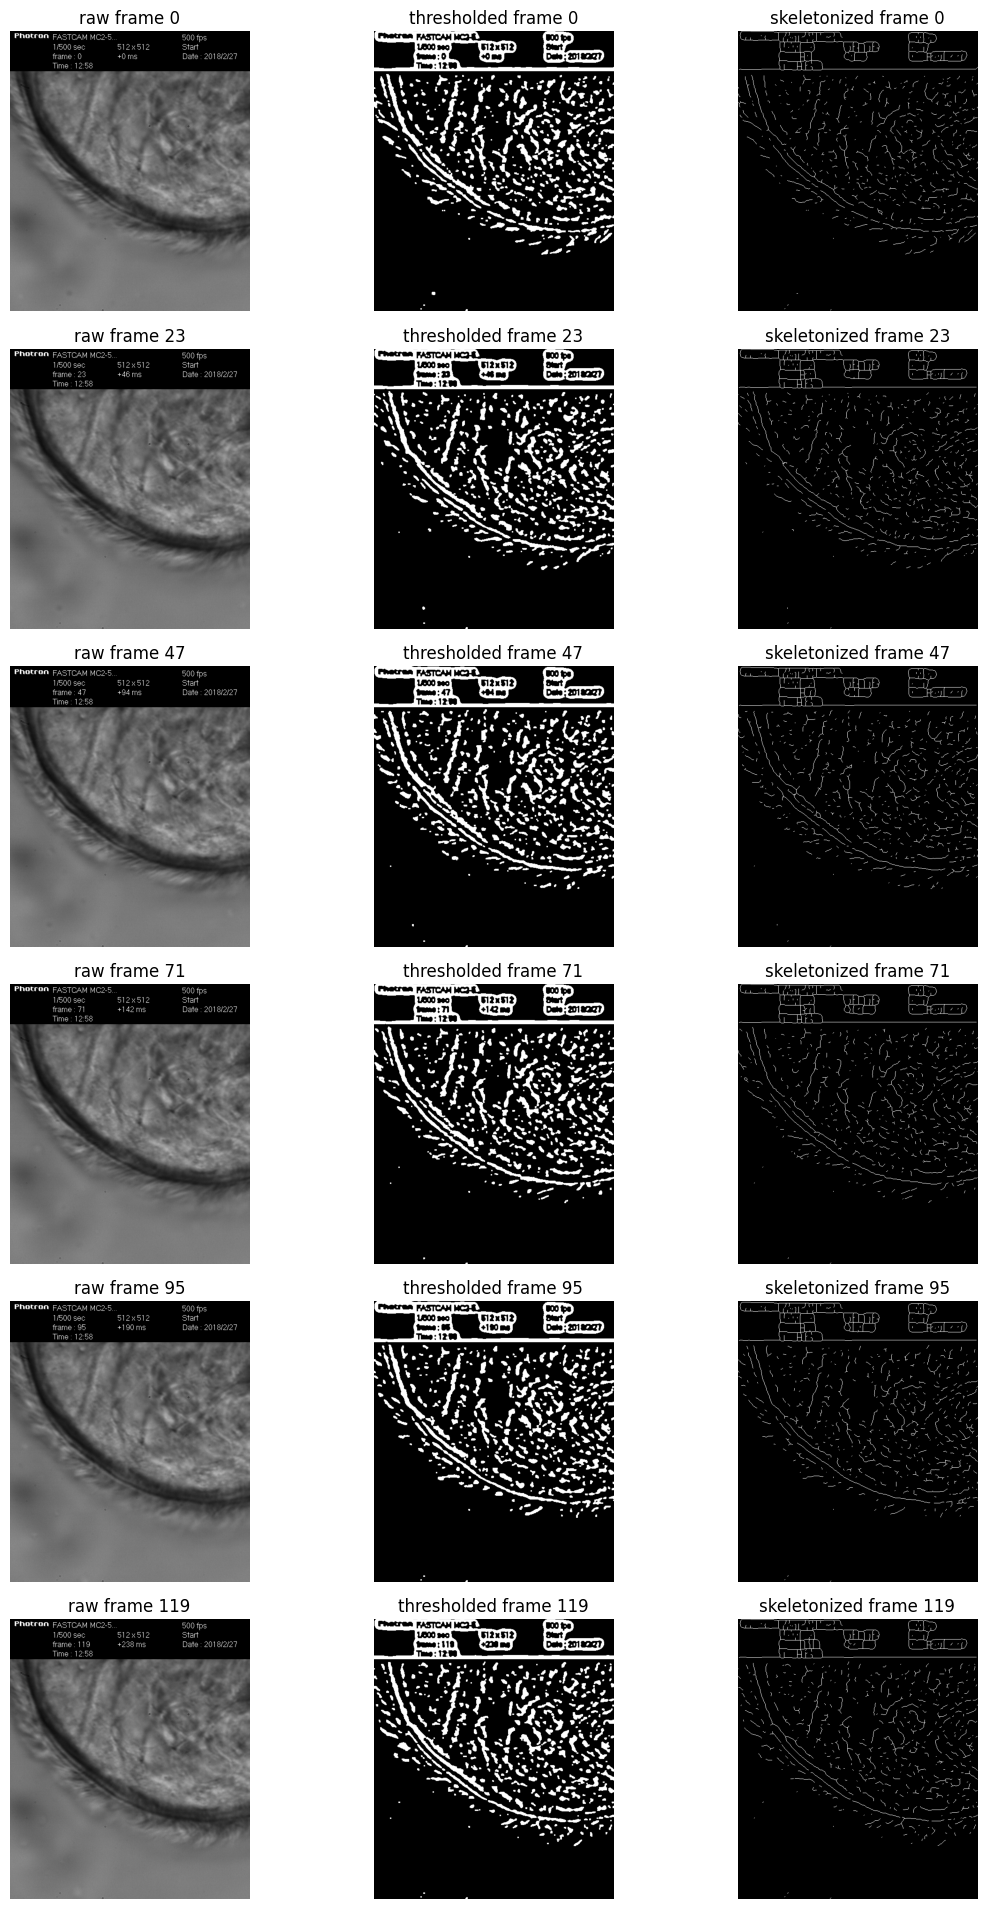

In [19]:
#show multiple thresholds and cskelenton images
if sample_video_path is not None:
    n_show = min(6, sample_video.shape[0])
    idxs = np.linspace(0, sample_video.shape[0] - 1, n_show, dtype=int)

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.2 * n_show))

    if n_show == 1:
        axes = np.array([axes])

    for row, idx in enumerate(idxs):
        frame_gray = sample_video[idx].astype(np.uint8)
        binary_img, skeleton_img = save_skeleton_demo(
            frame_gray,
            os.path.join(outdir, f"HERE_skeleton_demo_frame_{idx}.png")  # HERE ADDED
        )

        axes[row, 0].imshow(frame_gray, cmap='gray')
        axes[row, 0].set_title(f'raw frame {idx}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(binary_img, cmap='gray')
        axes[row, 1].set_title(f'thresholded frame {idx}')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(skeleton_img, cmap='gray')
        axes[row, 2].set_title(f'skeletonized frame {idx}')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()


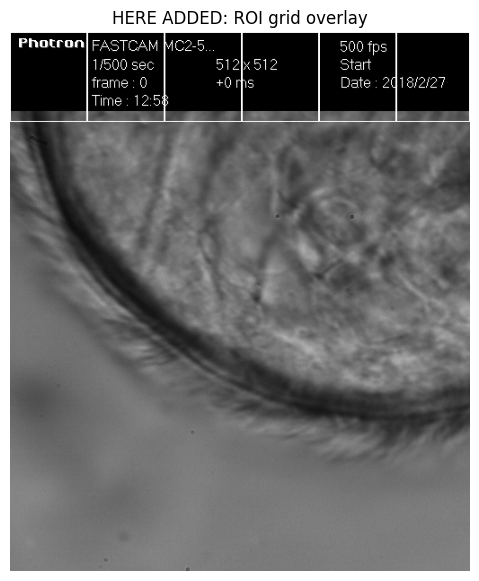

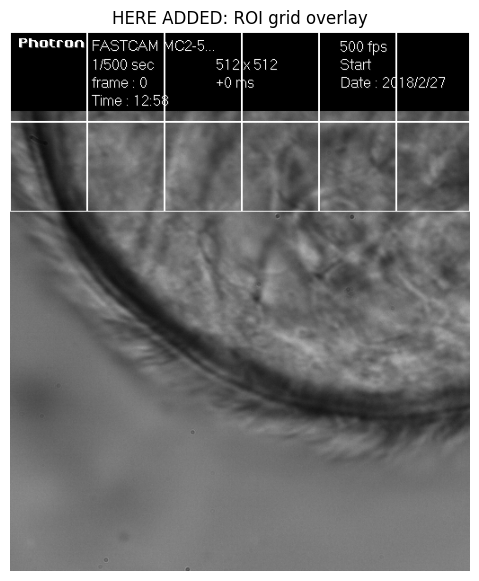

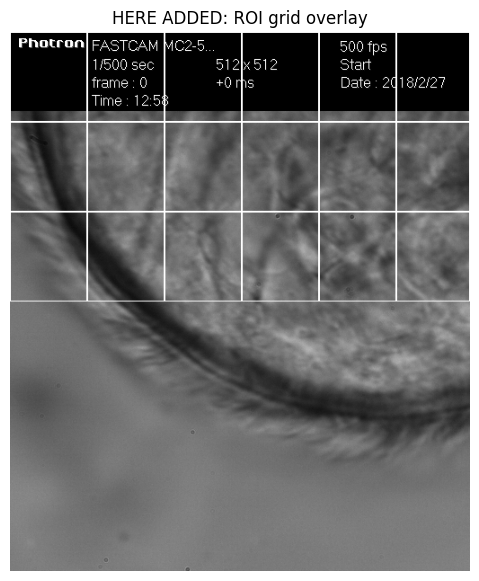

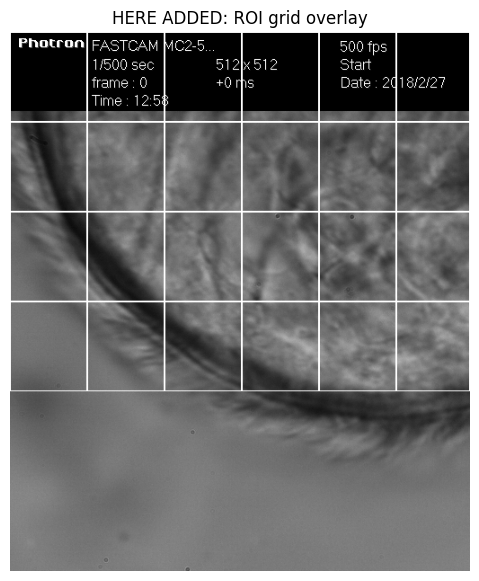

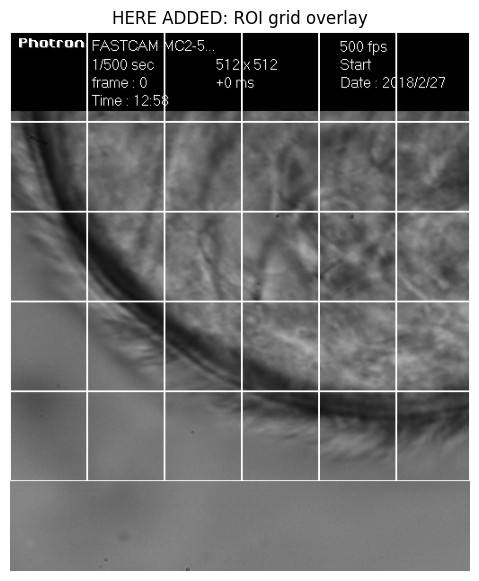

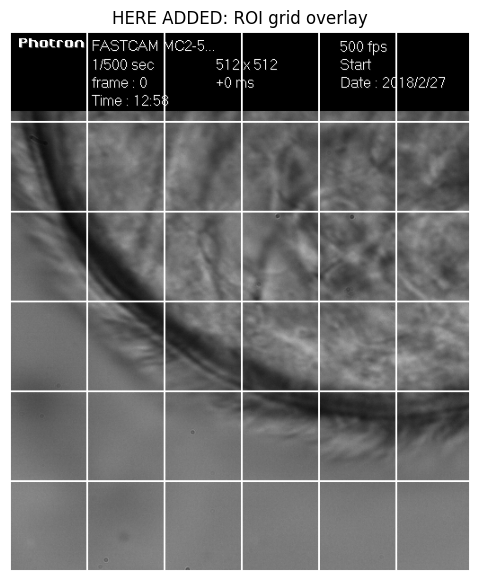

In [20]:
#Show ROi Grid on sample video:
if sample_video_path is not None:
    ngrid_demo = 6
frame_u8 = sample_video[0].astype(np.uint8)
display_img = cv2.cvtColor(frame_u8, cv2.COLOR_GRAY2BGR)

_, H, W = sample_video.shape
step_h = int(np.ceil(H / ngrid_demo))
step_w = int(np.ceil(W / ngrid_demo))

for gy in range(ngrid_demo):
    for gx in range(ngrid_demo):
            y0 = gy * step_h
            y1 = min((gy + 1) * step_h, H)
            x0 = gx * step_w
            x1 = min((gx + 1) * step_w, W)
            cv2.rectangle(display_img, (x0, y0), (x1 - 1, y1 - 1), (255, 255, 255), 1)

    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title('HERE ADDED: ROI grid overlay')
    plt.axis('off')
    plt.show()


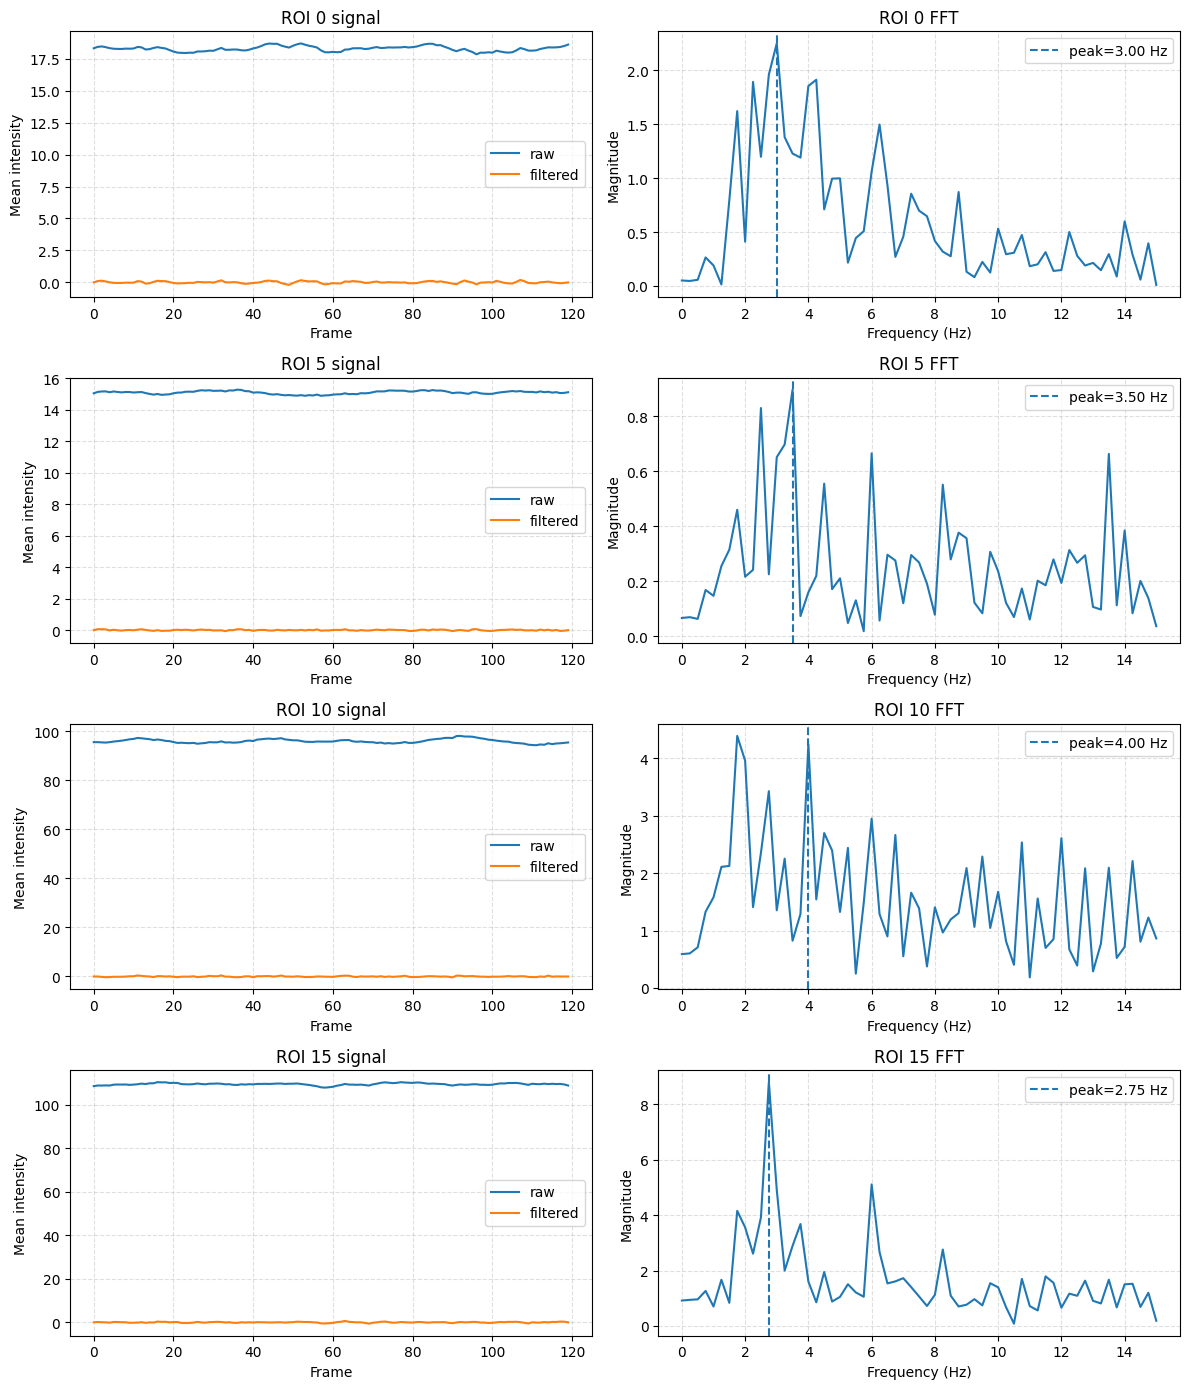

In [21]:
#Plot Multiple ROi's and their FFT analysis

if sample_video_path is not None:
    sample_rois, sample_meta = split_video(sample_video, n_split_axis=6)  
    roi_ids_to_show = [0, min(5, len(sample_rois)-1), min(10, len(sample_rois)-1), min(15, len(sample_rois)-1)]
    roi_ids_to_show = sorted(set([rid for rid in roi_ids_to_show if rid >= 0]))

    fig, axes = plt.subplots(len(roi_ids_to_show), 2, figsize=(12, 3.5 * len(roi_ids_to_show)))
    if len(roi_ids_to_show) == 1:
        axes = np.array([axes])

    for row, rid in enumerate(roi_ids_to_show):
        roi_cube = sample_rois[rid]
        raw_signal = roi_mean_intensity(roi_cube)
        peak_freq, peak_mag, filt_signal = fft_peak(raw_signal, sample_fps, fmin=2.0, fmax=30.0)

        spec = rfft(filt_signal)
        freqs = rfftfreq(len(filt_signal), d=1.0 / sample_fps)
        mags = np.abs(spec)
        mask = (freqs >= 0) & (freqs <= 40)

        axes[row, 0].plot(raw_signal, label='raw')
        axes[row, 0].plot(filt_signal, label='filtered')
        axes[row, 0].set_title(f'ROI {rid} signal')
        axes[row, 0].set_xlabel('Frame')
        axes[row, 0].set_ylabel('Mean intensity')
        axes[row, 0].legend()
        axes[row, 0].grid(True, linestyle='--', alpha=0.4)

        axes[row, 1].plot(freqs[mask], mags[mask])
        if not np.isnan(peak_freq):
            axes[row, 1].axvline(peak_freq, linestyle='--', label=f'peak={peak_freq:.2f} Hz')
            axes[row, 1].legend()
        axes[row, 1].set_title(f'ROI {rid} FFT')
        axes[row, 1].set_xlabel('Frequency (Hz)')
        axes[row, 1].set_ylabel('Magnitude')
        axes[row, 1].grid(True, linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.show()


In [22]:
#PREVIEW EXTRACTED VALUES
if os.path.exists(os.path.join(outdir, "cbf_per_video.csv")):
    df_preview = pd.read_csv(os.path.join(outdir, "cbf_per_video.csv"))
    print("Preview of extracted video-level features:")
    print(df_preview.head())

if os.path.exists(os.path.join(outdir, "cbf_per_roi.csv")):
    df_roi_preview = pd.read_csv(os.path.join(outdir, "cbf_per_roi.csv"))
    print("Preview of extracted ROI-level features:")
    print(df_roi_preview.head())

Preview of extracted video-level features:
        video label  cbf_hz    peak_mag        var       zcr
0   PCD_1.mp4   PCD   12.25   22.030402   0.052616  0.933110
1  PCD_10.mp4   PCD    8.40    9.410872   0.009372  0.538462
2  PCD_11.mov   PCD    9.00   29.392514   0.128223  0.591973
3  PCD_12.mov   PCD    4.30  375.675803  10.365746  0.391304
4  PCD_13.mov   PCD   15.00   21.481008   0.095938  0.539568
Preview of extracted ROI-level features:
                video  roi_id label    cbf_hz   peak_mag       var       zcr
0  ciliavideo (2).avi       0   PCD  2.000002   0.000000  0.000000  0.000000
1  ciliavideo (2).avi       1   PCD  2.000002   0.000000  0.000000  0.000000
2  ciliavideo (2).avi       2   PCD  6.000006  10.742325  0.029863  0.337793
3  ciliavideo (2).avi       3   PCD  6.000006  40.288191  0.075930  0.418060
4  ciliavideo (2).avi       4   PCD  6.000006  38.535238  0.070754  0.484950


In [23]:
#Add descriptive statistics and t-tests comparing PCD vs Healthy for the extracted CBF values
if os.path.exists(os.path.join(outdir, "cbf_per_video.csv")):
    df = pd.read_csv(os.path.join(outdir, "cbf_per_video.csv"))
    print("\nDescriptive statistics for video-level CBF:")
    print(df.groupby('label')['cbf_hz'].describe())

    pcd_cbf = df[df['label'] == 'PCD']['cbf_hz'].dropna()
    healthy_cbf = df[df['label'] == 'Healthy']['cbf_hz'].dropna()

    if len(pcd_cbf) > 1 and len(healthy_cbf) > 1:
        t_stat, p_value = stats.ttest_ind(pcd_cbf, healthy_cbf, equal_var=False, nan_policy='omit')
        print(f"\nWelch's t-test (PCD vs Healthy CBF): t={t_stat:.3f}, p={p_value:.3e}")
    else:
        print("\nNot enough data for t-test (need at least 2 samples in each group).")


Descriptive statistics for video-level CBF:
         count       mean       std       min       25%        50%     75%   max
label                                                                           
Healthy   12.0  12.926564  8.101775  2.185430  9.387500  12.500000  13.700  29.0
PCD       18.0  13.183309  8.895640  2.040816  7.333333  12.058339  14.975  29.4

Welch's t-test (PCD vs Healthy CBF): t=0.082, p=9.355e-01


Machine Learning Pipeline 

In [24]:
# Plotting Quantitative analysis of CBF resullts to classify between healthy and PCD samples. 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.stats import entropy as scipy_entropy
from scipy.stats import ttest_rel
import scipy.stats as stats

In [ ]:
# ADD
video_df = pd.read_csv(os.path.join(outdir, "cbf_per_video.csv"))

video_df["label_bin"] = video_df["label"].str.lower().map({
"healthy":0,
"pcd":1
})

video_df = pd.read_csv(
r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv"
)

mouse_df = pd.read_csv(
r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\Scaled.MT.csv"
)

mouse_df['label_bin'] = mouse_df['Group'].apply(
    lambda x: 0 if x.lower()=="control" else 1
)

mouse_df = mouse_df.rename(columns={
"CBF":"cbf_hz",
"SEM":"var"
})



mouse_df = mouse_df[['cbf_hz','var','label_bin']]

# Combine both datasets
combined_df = pd.concat([video_df, mouse_df], ignore_index=True)

print("Total samples:",combined_df.shape)

X = combined_df[['cbf_hz','var']]
y = combined_df['label_bin']

Total samples: (902, 3)


In [29]:

from sklearn.model_selection import train_test_split

X = combined_df[['cbf_hz','var']].values
y = combined_df['label_bin'].values

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape) 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test) 


#Uttility functions
def compute_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, prec, rec, f1

def plot_roc_curve(y_true, y_scores):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()



def plot_confusion_matrix(cm, classes, title='Confusion matrix'):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


    #Plot setup and result dictionary
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title('ROC Curve for Classifiers (CBF ROI Features)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(True, linestyle='--', alpha=0.7)

    results = {}

Train shape: (631, 2)
Test shape: (271, 2)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Fitting 3 folds for each of 12 candidates, totalling 36 fits


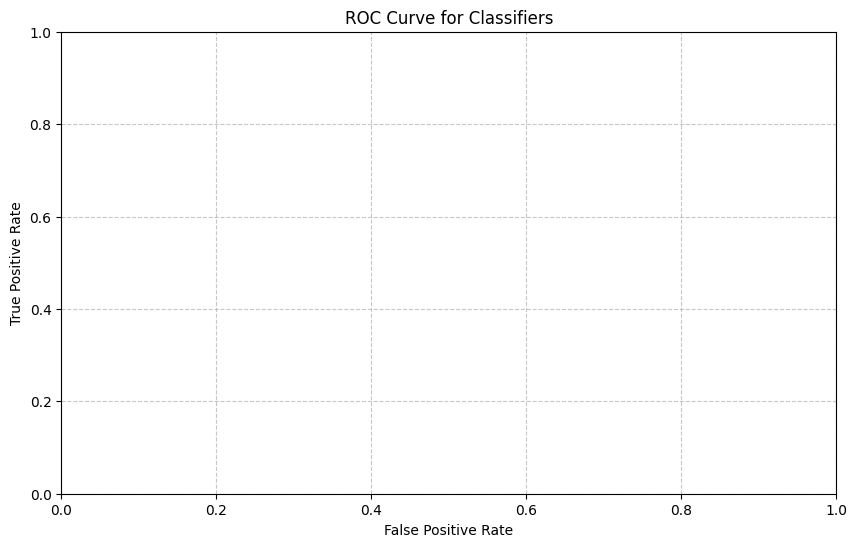

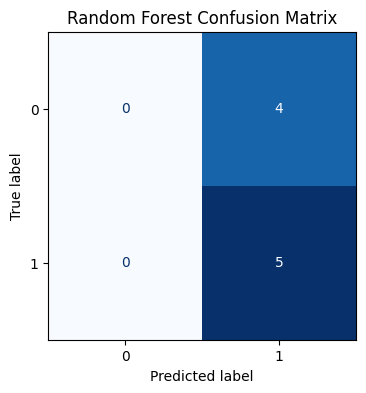

Fitting 3 folds for each of 24 candidates, totalling 72 fits


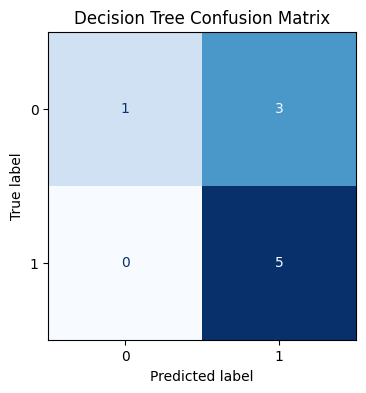

Fitting 3 folds for each of 108 candidates, totalling 324 fits


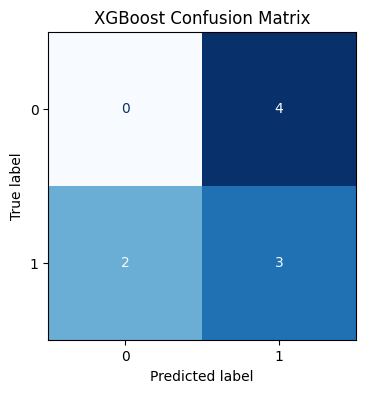

Fitting 3 folds for each of 6 candidates, totalling 18 fits


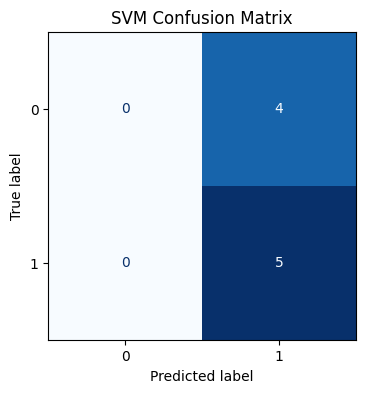

Reloading Tuner from cnn_tuning_dir\cnn_tuning\tuner0.json
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4375 - loss: 0.7243 - val_accuracy: 0.2000 - val_loss: 0.7521
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4375 - loss: 0.7099 - val_accuracy: 0.2000 - val_loss: 0.7159
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4375 - loss: 0.6988 - val_accuracy: 0.8000 - val_loss: 0.6842
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5625 - loss: 0.6913 - val_accuracy: 0.8000 - val_loss: 0.6575
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5625 - loss: 0.6871 - val_accuracy: 0.8000 - val_loss: 0.6358
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5625 - loss: 0.6857 - val_accuracy: 0.8000 - val_loss: 0.6191
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5625 - loss: 0.6864 - val_accuracy: 0.8000 - val_loss: 0.6069
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5625 

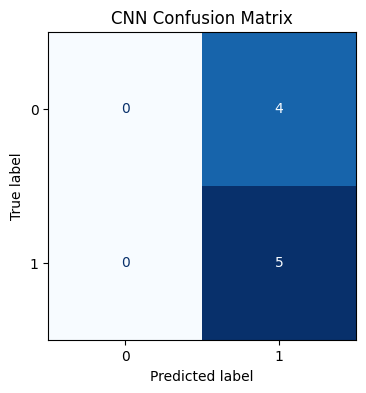

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Reloading Tuner from rnn_tuning_dir\rnn_tuning\tuner0.json
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5625 - loss: 0.6896 - val_accuracy: 0.8000 - val_loss: 0.5788
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5625 - loss: 0.7082 - val_accuracy: 0.8000 - val_loss: 0.6119
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5625 - loss: 0.6884 - val_accuracy: 0.8000 - val_loss: 0.6585
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5625 - loss: 0.6868 - val_accuracy: 0.8000 - val_loss: 0.6819
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6250 - loss: 0.6901 - val_accuracy: 0.8000 - val_loss: 0.6775
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6875 - loss: 0.6885 - val_accuracy: 0.8000 - val_loss: 0.6586
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5625 - loss: 0.6849 - val_accuracy: 0.8000 - val_loss: 0.6368
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━

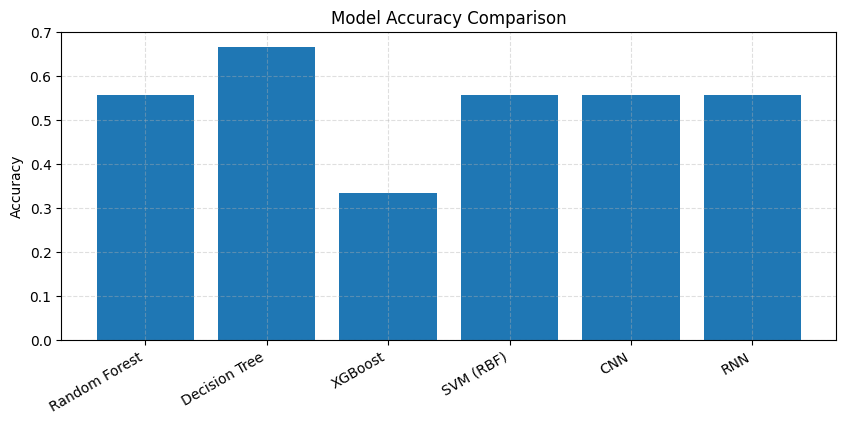

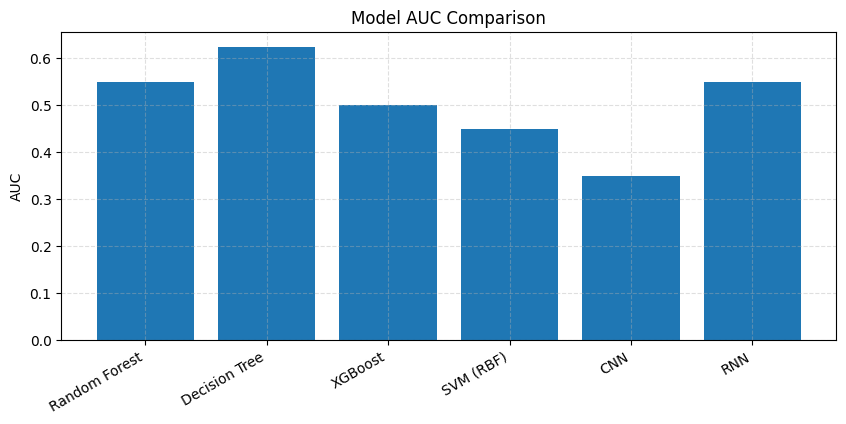

In [35]:
%pip install tensorflow keras-tuner
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.svm import SVC  # SVM classifier
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
import warnings
warnings.filterwarnings("ignore")

# --- Utility function to compute sensitivity and specificity ---
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity, specificity

# Define the path to your data file
data_path = r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv"

df = pd.read_csv(data_path)

df = df.rename(columns={"cbf_hz": "CBF"})
df = df[["video","label","CBF"]]

df["label"] = df["label"].astype(str).str.lower().map({"pcd":1,"healthy":0})

df = df.dropna(subset=["CBF","label"]).reset_index(drop=True)

x = df[["CBF"]].to_numpy()
y = df["label"].astype(int).to_numpy()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# --- Function to plot ROC curve and compute AUC for a given model ---
def plot_roc_auc(model, x_test, y_test, model_name, ax):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = model.predict(x_test).ravel()

    
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    return roc_auc, y_prob

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("ROC Curve for Classifiers")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(True, linestyle='--', alpha=0.7)

results = {}

#confusion matrix plotting function 
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confmat(y_test, y_pred, title):
    fig_cm, ax_cm = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax_cm, cmap="Blues", colorbar=False
    )
    ax_cm.set_title(title)
    plt.show()


# 1. Random Forest Classifier (GridSearchCV)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(x_train_scaled, y_train)
best_rf_model = rf_grid.best_estimator_
rf_pred = best_rf_model.predict(x_test_scaled)
plot_confmat(y_test, rf_pred, "Random Forest Confusion Matrix")
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc, _ = plot_roc_auc(best_rf_model, x_test_scaled, y_test, "Random Forest (Tuned)", ax)
rf_sens, rf_spec = compute_sensitivity_specificity(y_test, rf_pred)
results["Random Forest"] = {
    "Accuracy": rf_accuracy,
    "AUC": rf_auc,
    "Sensitivity": rf_sens,
    "Specificity": rf_spec
}


# 2. Decision Tree Classifier (GridSearchCV)
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_model = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt_model, dt_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
dt_grid.fit(x_train_scaled, y_train)
best_dt_model = dt_grid.best_estimator_
dt_pred = best_dt_model.predict(x_test_scaled)
plot_confmat(y_test, dt_pred, "Decision Tree Confusion Matrix")
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_auc, _ = plot_roc_auc(best_dt_model, x_test_scaled, y_test, "Decision Tree (Tuned)", ax)
dt_sens, dt_spec = compute_sensitivity_specificity(y_test, dt_pred)
results["Decision Tree"] = {
    "Accuracy": dt_accuracy,
    "AUC": dt_auc,
    "Sensitivity": dt_sens,
    "Specificity": dt_spec
}

# 3. XGBoost Classifier (GridSearchCV)

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=44)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
xgb_grid.fit(x_train_scaled, y_train)
best_xgb_model = xgb_grid.best_estimator_
xgb_pred = best_xgb_model.predict(x_test_scaled)
plot_confmat(y_test, xgb_pred, "XGBoost Confusion Matrix")
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_auc, _ = plot_roc_auc(best_xgb_model, x_test_scaled, y_test, "XGBoost (Tuned)", ax)
xgb_sens, xgb_spec = compute_sensitivity_specificity(y_test, xgb_pred)
results["XGBoost"] = {
    "Accuracy": xgb_accuracy,
    "AUC": xgb_auc,
    "Sensitivity": xgb_sens,
    "Specificity": xgb_spec
}

# 4. Support Vector Machine (SVM) with RBF Kernel (GridSearchCV)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}
svm_model = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm_model, svm_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(x_train_scaled, y_train)
best_svm_model = svm_grid.best_estimator_
svm_pred = best_svm_model.predict(x_test_scaled)
plot_confmat(y_test, svm_pred, "SVM Confusion Matrix")
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_auc, _ = plot_roc_auc(best_svm_model, x_test_scaled, y_test, "SVM (Tuned)", ax)
svm_sens, svm_spec = compute_sensitivity_specificity(y_test, svm_pred)
results["SVM (RBF)"] = {
    "Accuracy": svm_accuracy,
    "AUC": svm_auc,
    "Sensitivity": svm_sens,
    "Specificity": svm_spec
}

# 5. Convolutional Neural Network (CNN) using Keras Tuner
def build_cnn_model(hp):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))
    filters = hp.Choice('filters', values=[32, 64])
    kernel_size = hp.Choice('kernel_size', values=[1, 3])
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
    model.add(Flatten())
    dense_units = hp.Choice('dense_units', values=[32, 64])
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-2])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare data for CNN (add channel dimension)
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

cnn_tuner = kt.RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='cnn_tuning_dir',
    project_name='cnn_tuning'
)
cnn_tuner.search(x_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=1)
best_cnn_hps = cnn_tuner.get_best_hyperparameters(num_trials=1)[0]
best_cnn_model = cnn_tuner.hypermodel.build(best_cnn_hps)
# Optionally, further train the best model
best_cnn_model.fit(x_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=1)
cnn_pred = (best_cnn_model.predict(x_test_cnn).flatten() > 0.5).astype(int)
plot_confmat(y_test, cnn_pred, "CNN Confusion Matrix")
cnn_accuracy = accuracy_score(y_test, cnn_pred)
fpr, tpr, _ = roc_curve(y_test, best_cnn_model.predict(x_test_cnn).flatten())
cnn_auc = auc(fpr, tpr)
cnn_sens, cnn_spec = compute_sensitivity_specificity(y_test, cnn_pred)
ax.plot(fpr, tpr, label=f"CNN (Tuned, AUC = {cnn_auc:.2f})")
results["CNN"] = {
    "Accuracy": cnn_accuracy,
    "AUC": cnn_auc,
    "Sensitivity": cnn_sens,
    "Specificity": cnn_spec
}

# 6. Recurrent Neural Network (RNN - LSTM) using Keras Tuner
def build_rnn_model(hp):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))
    lstm_units = hp.Choice('lstm_units', values=[32, 64])
    model.add(LSTM(lstm_units))
    dense_units = hp.Choice('dense_units', values=[32, 64])
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-2])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare data for RNN (add time steps dimension)
x_train_rnn = np.expand_dims(x_train, axis=2)
x_test_rnn = np.expand_dims(x_test, axis=2)

rnn_tuner = kt.RandomSearch(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='rnn_tuning_dir',
    project_name='rnn_tuning'
)
rnn_tuner.search(x_train_rnn, y_train, epochs=10, validation_split=0.2, verbose=1)
best_rnn_hps = rnn_tuner.get_best_hyperparameters(num_trials=1)[0]
best_rnn_model = rnn_tuner.hypermodel.build(best_rnn_hps)
# Optionally, further train the best model
best_rnn_model.fit(x_train_rnn, y_train, epochs=10, validation_split=0.2, verbose=1)
rnn_pred = (best_rnn_model.predict(x_test_rnn).flatten() > 0.5).astype(int)

rnn_accuracy = accuracy_score(y_test, rnn_pred)
fpr, tpr, _ = roc_curve(y_test, best_rnn_model.predict(x_test_rnn).flatten())
rnn_auc = auc(fpr, tpr)
rnn_sens, rnn_spec = compute_sensitivity_specificity(y_test, rnn_pred)
ax.plot(fpr, tpr, label=f"RNN (Tuned, AUC = {rnn_auc:.2f})")
results["RNN"] = {
    "Accuracy": rnn_accuracy,
    "AUC": rnn_auc,
    "Sensitivity": rnn_sens,
    "Specificity": rnn_spec
}

# --- Finalize ROC plot ---
ax.legend(loc="lower right")
plt.show()

# --- Print accuracy, AUC, sensitivity, and specificity for each model ---
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.2f}")
    print(f"  AUC: {metrics['AUC']:.2f}")
    print(f"  Sensitivity: {metrics['Sensitivity']:.2f}")
    print(f"  Specificity: {metrics['Specificity']:.2f}")


#summary bar plots
import pandas as pd

res_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

# Accuracy bar
plt.figure(figsize=(10, 4))
plt.bar(res_df["Model"], res_df["Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# AUC bar
plt.figure(figsize=(10, 4))
plt.bar(res_df["Model"], res_df["AUC"])
plt.xticks(rotation=30, ha="right")
plt.title("Model AUC Comparison")
plt.ylabel("AUC")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [36]:

#use combined dataset to train a simple classifier and evaluate its performance

X = combined_df[['cbf_hz','var']].values
y = combined_df['label_bin'].values

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("train shape =", x_train.shape)
print("test shape =", x_test.shape)

train shape = (631, 2)
test shape = (271, 2)


In [39]:
# HERE ADDED: utility functions for the clean ML section

def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return sensitivity, specificity

def plot_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

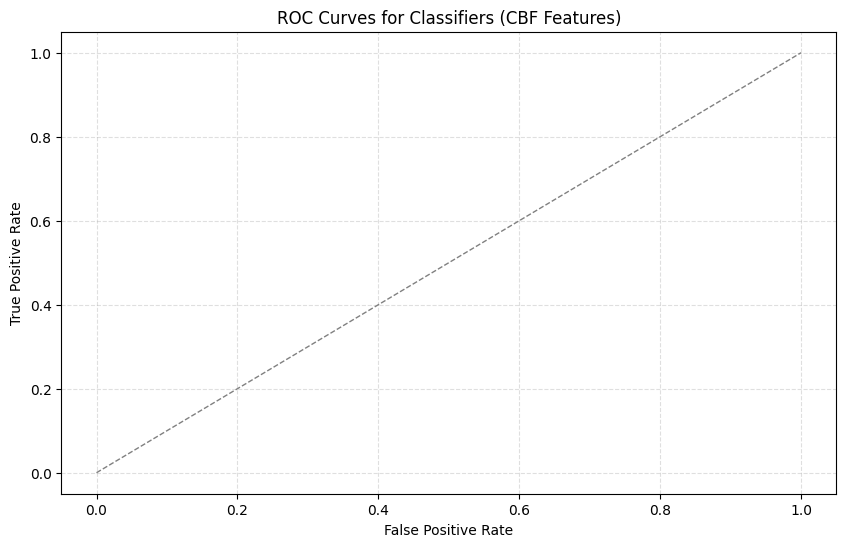

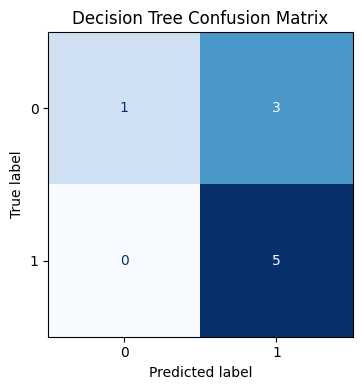

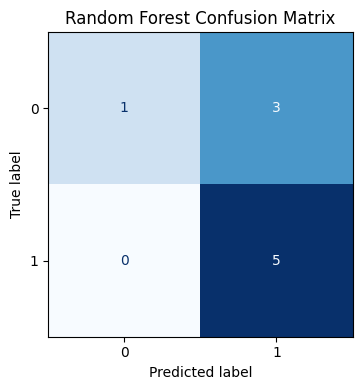

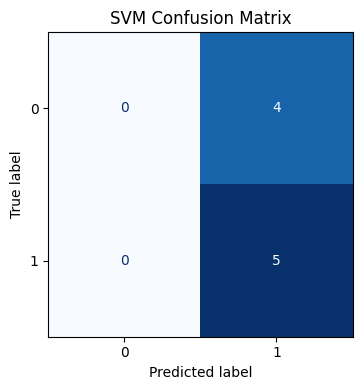

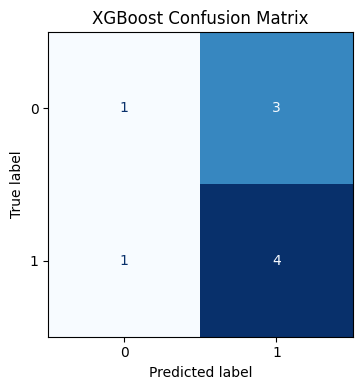

           Model  Accuracy  Precision  Recall        F1  Sensitivity  Specificity
0  Decision Tree  0.666667   0.625000     1.0  0.769231          1.0         0.25
1  Random Forest  0.666667   0.625000     1.0  0.769231          1.0         0.25
2            SVM  0.555556   0.555556     1.0  0.714286          1.0         0.00
3        XGBoost  0.555556   0.571429     0.8  0.666667          0.8         0.25


In [40]:
# HERE ADDED: train models, ROC curves, confusion matrices, and final table
results = {}

if not ml_df.empty:
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            random_state=42
        )
    }
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_title('ROC Curves for Classifiers (CBF Features)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(True, linestyle='--', alpha=0.4)

    for model_name, model in models.items():
        Xtr = x_train_scaled if model_name == 'SVM' else x_train
        Xte = x_test_scaled if model_name == 'SVM' else x_test
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        metrics = compute_metrics(y_test, y_pred)
        sens, spec = sensitivity_specificity(y_test, y_pred)
        results[model_name] = {**metrics, 'Sensitivity': sens, 'Specificity': spec}
        plot_confusion_matrix(y_test, y_pred, f"{model_name} Confusion Matrix")
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(Xte)[:, 1]
        else:
            y_prob = model.decision_function(Xte)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    ax.legend(loc="lower right")
    plt.show()
    results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
    print(results_df)

    # Save the results to a CSV file
    results_df.to_csv('results.csv', index=False)
